In [1]:
from __future__ import annotations
import os, time, math
os.environ['OMP_NUM_THREADS']='1'
os.environ['MKL_NUM_THREADS']='1'
os.environ['OPENBLAS_NUM_THREADS']='1'
os.environ['VECLIB_MAXIMUM_THREADS']='1'
os.environ['NUMEXPR_NUM_THREADS']='1'

import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Sequence

import matplotlib.pyplot as plt
import numpy as np

# Ensure local negf package is on the path
_here = Path().resolve()
_candidates = [_here, * _here.parents]
for base in _candidates:
    if (base / "negf").is_dir():
        sys.path.insert(0, str(base))
        break
    if (base / "src" / "negf").is_dir():
        sys.path.insert(0, str(base / "src"))
        break
else:
    raise ModuleNotFoundError("Cannot locate the negf package. Check the project path resolution.")

from negf.gf.recursive_greens_functions import gf_inverse, _variable_recursive_inverse, _recursive_inverse
from negf import sancho_rubio_iterative_greens_function, surface_greens_function_nn
from negf.utils.block_partition import (
    compute_block_sizes_block_tridiagonal,
    compute_block_sizes_metis,
 )

from pathlib import Path
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

# Load QuantumATK reference data
_data_dir = Path("../DFT_data/TB_silicon_nw").resolve()

# Load hamiltonians

In [2]:
coords = np.load(_data_dir / "central_coords_angstrom.npy")
elems = np.load(_data_dir / "central_elements.npy")

## hamiltonian validation via DOS

In [3]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from negf.utils.block_partition import compute_block_sizes_metis
from negf.self_energy.greens_functions import surface_greens_function_nn
from negf.gf.recursive_greens_functions import _variable_recursive_inverse, _recursive_inverse, _direct_inverse

mapping = {"Si": 10, "H": 0}
counts_raw = np.array([mapping[str(e)] for e in elems], dtype=int)
mask = counts_raw > 0
counts = counts_raw[mask]
atom_offsets = np.concatenate(([0], np.cumsum(counts)))
np.save(_data_dir / "atom_offsets.npy", atom_offsets)

# Extract principal-layer blocks and couplings
_data_dir = Path("../DFT_data/TB_silicon_nw").resolve()
energy = np.load(_data_dir / "Energy_grid.npy")
H_device = np.load(_data_dir / "H_device.npy")
S_device = np.load(_data_dir / "S_device.npy")
sigma_L_ref = np.load(_data_dir / "Sigma_L_stack.npy")
sigma_R_ref = np.load(_data_dir / "Sigma_R_stack.npy")
H_left = np.load(_data_dir / "H_left.npy")
S_left = np.load(_data_dir / "S_left.npy")
H_right = np.load(_data_dir / "H_right.npy")
S_right = np.load(_data_dir / "S_right.npy")

n = H_left.shape[0] * 2
H_left = H_device[:n, :n]
S_left = S_device[:n, :n]
H_right = H_device[-n:, -n:]
S_right = S_device[-n:, -n:]
H01_L = H_device[:n, n:2*n]
H10_L = H_device[n:2*n, :n]
S01_L = S_device[:n, n:2*n]
S10_L = S_device[n:2*n, :n]
H01_R = H_device[-n:, -2*n:-n]
H10_R = H_device[-2*n:-n, -n:]
S01_R = S_device[-n:, -2*n:-n]
S10_R = S_device[-2*n:-n, -n:]
_eta = 1e-6
_damp = 1e-6
_tol = 1e-10

# METIS-based variable block sizes
block_sizes = compute_block_sizes_metis(
    H_device,
    H_left,
    H_right,
    atom_offsets=atom_offsets,
    min_block_orbitals=n,
    )

# sigma_L_sr = np.array([
#     sancho_rubio_iterative_greens_function(
#         float(E),
#         h_l=H01_L,
#         h_0=H_left,
#         h_r=H10_L,
#         s_l=S01_L,
#         s_0=S_left,
#         s_r=S10_L,
#         damp=_damp,
#         nconv=_tol,
#     )
#     for E in energy
# ])

# sigma_R_sr = np.array([
#     sancho_rubio_iterative_greens_function(
#         float(E),
#         h_l=H01_R,
#         h_0=H_right,
#         h_r=H10_R,
#         s_l=S01_R,
#         s_0=S_right,
#         s_r=S10_R,
#         damp=_damp,
#         nconv=_tol,
#     )
#     for E in energy
# ])


sigma_L_sr = np.load(_data_dir / "Sigma_L_stack.npy")
sigma_R_sr = np.load(_data_dir / "Sigma_R_stack.npy")



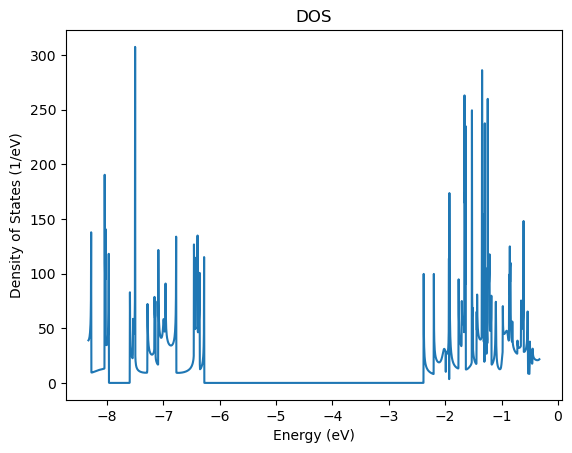

In [4]:

def embed_sigma(sigL, sigR):
    out = np.zeros_like(H_device, dtype=complex)
    a = sigL.shape[0]
    out[:a, :a] += sigL
    out[-a:, -a:] += sigR
    return out


rho_sr = []
for E, sigL_sr, sigR_sr in zip(energy, sigma_L_sr, sigma_R_sr):
    Sigma_sr = embed_sigma(sigL_sr, sigR_sr)


    #G_R_diag, _,_,_, Gamma_R, trace_gs = _variable_recursive_inverse(E, H_device, Sigma_L = sigL_sr, Sigma_R = sigR_sr, block_size_list=block_sizes,mu1 = -4.328434, mu2 = -4.328434, overlap_matrix = S_device, processes = 16)
    G_R_diag, G_lesser_diag, G_lesser_offdiag_right, Gamma_L, Gamma_R, trace_gs = _recursive_inverse(
    E,
    H_device,
    sigL_sr,
    sigR_sr,
    compute_lesser=True,
    overlap_matrix = S_device,
    return_trace = True)
    rho_sr.append(-np.imag(trace_gs) / np.pi)

rho_sr = np.array(rho_sr)

plt.plot(energy, rho_sr)
plt.xlabel("Energy (eV)")
plt.ylabel("Density of States (1/eV)")
plt.title("DOS")
plt.show()

In [5]:
# test transmission
# Use full retarded Green's function from _variable_recursive_inverse to compute T(E)
transmission_sr = []


def _embed_gamma(gamma: np.ndarray, side: str) -> np.ndarray:
    full = np.zeros_like(H_device, dtype=complex)
    m = gamma.shape[0]
    if side == "left":
        full[:m, :m] = gamma
    else:
        full[-m:, -m:] = gamma
    return full


for E, sigL_sr, sigR_sr in zip(energy, sigma_L_sr, sigma_R_sr):
    G_R_diag, G_R_blocks, G_R_full, Gamma_L, Gamma_R, _ = _variable_recursive_inverse(
        E,
        H_device,
        Sigma_L=sigL_sr,
        Sigma_R=sigR_sr,
        block_size_list=block_sizes,
        processes=16,
        overlap_matrix=S_device,
        return_full_inverse=True,
    )

    Gamma_L_full = _embed_gamma(Gamma_L, "left")
    Gamma_R_full = _embed_gamma(Gamma_R, "right")

    G_A_full = G_R_full.conj().T
    T_E = np.real(np.trace(Gamma_L_full @ G_R_full @ Gamma_R_full @ G_A_full))
    transmission_sr.append(T_E)

transmission_sr = np.asarray(transmission_sr)

plt.figure(figsize=(6, 3.5))
plt.plot(energy, transmission_sr)
plt.xlabel("Energy (eV)")
plt.ylabel("Transmission")
plt.title("Transmission vs energy (Sancho-Rubio)")
plt.grid(True)
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

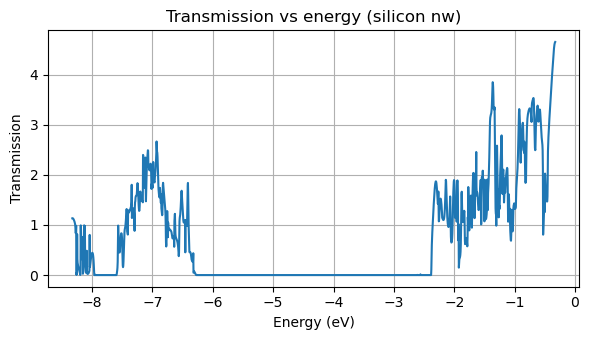

In [ ]:
plt.figure(figsize=(6, 3.5))
plt.plot(energy, transmission_sr)
plt.xlabel("Energy (eV)")
plt.ylabel("Transmission")
plt.title("Transmission vs energy (silicon nw)")
plt.grid(True)
plt.tight_layout()
plt.show()

## LDOS variation along transport axis

In [12]:

import numpy as np
import matplotlib.pyplot as plt

try:
    from scipy.ndimage import gaussian_filter1d
except Exception:
    gaussian_filter1d = None

# Settings
transport_axis = 2  # 0=x, 1=y, 2=z (QuantumATK coords here are in Angstrom)
z_units = "nm"
nbins_z = 80
smooth_sigma_eV = 0.05  # Gaussian sigma in eV for smoothing along energy axis
energy_stride = 1  # increase (e.g. 2, 5, 10) if this takes too long

# Inputs expected from earlier cells
energies = np.asarray(energy, dtype=float)
if energies.ndim != 1:
    raise ValueError("Expected 1D energy grid in variable 'energy'.")

z_atoms = np.asarray(coords[mask][:, transport_axis], dtype=float)
# Angstrom -> nm
if z_units == "nm":
    z_atoms = z_atoms * 0.1

# Bin edges/centers
z_edges = np.linspace(float(z_atoms.min()), float(z_atoms.max()), int(nbins_z) + 1)
z_centers = 0.5 * (z_edges[:-1] + z_edges[1:])
dz = np.diff(z_edges)

# Helper: sum orbital-resolved quantity to atoms using precomputed atom_offsets
# atom_offsets has length n_atoms+1, built earlier from 'counts'
if "atom_offsets" not in globals():
    # Fallback: build offsets from counts
    atom_offsets = np.concatenate(([0], np.cumsum(np.asarray(counts, dtype=int))))

atom_offsets = np.asarray(atom_offsets, dtype=int)
if atom_offsets.ndim != 1 or atom_offsets.size < 2:
    raise ValueError("atom_offsets must be a 1D array with length n_atoms+1")

n_atoms = atom_offsets.size - 1
if z_atoms.shape[0] != n_atoms:
    raise ValueError(
        f"coords[mask] has {z_atoms.shape[0]} atoms but atom_offsets implies {n_atoms} atoms. "
        "Check that 'mask' and 'counts/atom_offsets' refer to the same device atom ordering."
    )

# Preallocate LDOS grid
idxs = np.arange(0, energies.size, int(energy_stride))
energies_eval = energies[idxs]
ldos_z = np.zeros((energies_eval.size, z_centers.size), dtype=float)

for ii, (E, sigL, sigR) in enumerate(zip(energies_eval, sigma_L_sr[idxs], sigma_R_sr[idxs])):
    # Retarded Green's function diagonal (orbital-resolved)
    G_R_diag, *_ = _recursive_inverse(
        float(E),
        H_device,
        sigL,
        sigR,
        compute_lesser=False,
        overlap_matrix=S_device,
        return_trace=False,
    )

    # Orbital LDOS: -Im(G^R_ii)/pi
    ldos_orb = (-np.imag(G_R_diag) / np.pi).astype(float, copy=False)

    # Sum orbitals -> atoms
    atom_ldos = np.add.reduceat(ldos_orb, atom_offsets[:-1])

    # Project atoms -> z grid (per length)
    hist, _ = np.histogram(z_atoms, bins=z_edges, weights=atom_ldos)
    ldos_z[ii, :] = hist / dz


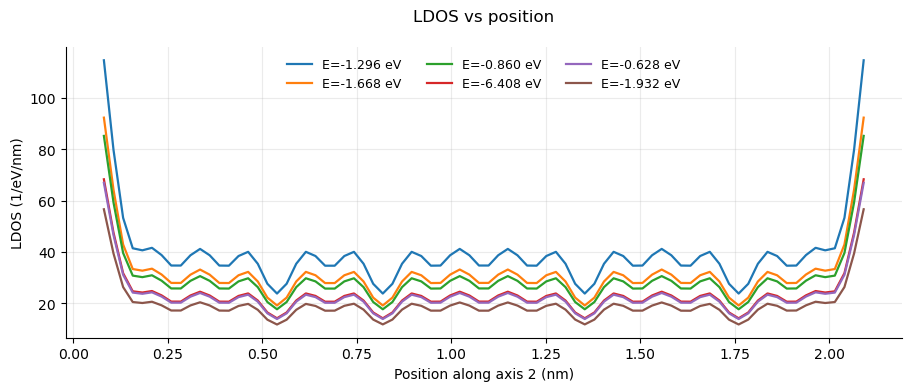

In [18]:
# LDOS vs position z (with energy + spatial broadening)

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks, fftconvolve

# Settings
energy_broadening = "gaussian"  # "gaussian", "lorentzian", "none"
space_broadening = "gaussian"   # "gaussian", "lorentzian", "none"
sigma_E_eV = 0.05                # Gaussian sigma in eV
gamma_E_eV = 0.005                # Lorentzian HWHM in eV
sigma_z = 0.05                 # Gaussian sigma in z_units (nm)
gamma_z = 0.25                   # Lorentzian HWHM in z_units (nm)

energies_to_plot = None          # e.g. [-0.2, 0.0, 0.2]
n_energy_curves = 6
# Helpers
def _sigma_in_points(width_physical: float, grid: np.ndarray) -> float:
    grid = np.asarray(grid, dtype=float)
    if grid.size < 2:
        return 0.0
    d = float(np.median(np.diff(grid)))
    if not np.isfinite(d) or d <= 0:
        return 0.0
    return max(0.0, float(width_physical) / d)

def _lorentzian_kernel_1d(gamma_pts: float) -> np.ndarray:
    gamma_pts = float(gamma_pts)
    if not np.isfinite(gamma_pts) or gamma_pts <= 0:

        return np.array([1.0], dtype=float)

    half_width = int(np.ceil(8.0 * gamma_pts))

    x = np.arange(-half_width, half_width + 1, dtype=float)

    k = 1.0 / (1.0 + (x / gamma_pts) ** 2)

    k_sum = float(k.sum())

    return k / k_sum if k_sum > 0 else np.array([1.0], dtype=float)

def _smooth_along_axis(arr: np.ndarray, axis: int, method: str, sigma_pts: float, gamma_pts: float) -> np.ndarray:

    method = str(method).lower()

    arr = np.asarray(arr, dtype=float)

    if method in ("none", "off", "false") or arr.size == 0:

        return arr

    if method == "gaussian":

        if gaussian_filter1d is None or sigma_pts <= 0:

            return arr

        return gaussian_filter1d(arr, sigma=float(sigma_pts), axis=axis, mode="nearest")

    if method == "lorentzian":

        if gamma_pts <= 0:

            return arr

        k = _lorentzian_kernel_1d(gamma_pts)

        if fftconvolve is None:

            return np.apply_along_axis(lambda v: np.convolve(v, k, mode="same"), axis, arr)

        return np.apply_along_axis(lambda v: fftconvolve(v, k, mode="same"), axis, arr)

    return arr

def _broadening_tag() -> str:

    if energy_broadening == "gaussian":

        e_tag = f"E: Gauss σ={sigma_E_eV:.3f} eV"

    elif energy_broadening == "lorentzian":

        e_tag = f"E: Lorentz γ={gamma_E_eV:.3f} eV"

    else:

        e_tag = "E: none"

    if space_broadening == "gaussian":

        z_tag = f"z: Gauss σ={sigma_z:.3f} {z_units}"

    elif space_broadening == "lorentzian":

        z_tag = f"z: Lorentz γ={gamma_z:.3f} {z_units}"

    else:

        z_tag = "z: none"

    return f"{e_tag}, {z_tag}"

# Smooth LDOS(E,z)

energies_eval = np.asarray(energies_eval, dtype=float)

z_centers = np.asarray(z_centers, dtype=float)

ldos_z = np.asarray(ldos_z, dtype=float)

if energy_broadening == "gaussian":

    sigma_E_pts = _sigma_in_points(sigma_E_eV, energies_eval)

    gamma_E_pts = 0.0

elif energy_broadening == "lorentzian":

    sigma_E_pts = 0.0

    gamma_E_pts = _sigma_in_points(gamma_E_eV, energies_eval)

else:

    sigma_E_pts = 0.0

    gamma_E_pts = 0.0

ldos_s = _smooth_along_axis(ldos_z, axis=0, method=energy_broadening, sigma_pts=sigma_E_pts, gamma_pts=gamma_E_pts)

if space_broadening == "gaussian":

    sigma_z_pts = _sigma_in_points(sigma_z, z_centers)

    gamma_z_pts = 0.0

elif space_broadening == "lorentzian":

    sigma_z_pts = 0.0

    gamma_z_pts = _sigma_in_points(gamma_z, z_centers)

else:

    sigma_z_pts = 0.0

    gamma_z_pts = 0.0

ldos_s = _smooth_along_axis(ldos_s, axis=1, method=space_broadening, sigma_pts=sigma_z_pts, gamma_pts=gamma_z_pts)

# Choose energies

if energies_to_plot is None:

    score = np.nanmean(ldos_s, axis=1)

    if find_peaks is not None and score.size >= 3:

        peaks, _ = find_peaks(score)

        if peaks.size > 0:

            peaks = peaks[np.argsort(score[peaks])[::-1]][: int(n_energy_curves)]

            energies_to_plot = energies_eval[peaks]

        else:

            energies_to_plot = np.linspace(energies_eval.min(), energies_eval.max(), int(n_energy_curves))

    else:

        energies_to_plot = np.linspace(energies_eval.min(), energies_eval.max(), int(n_energy_curves))

energies_to_plot = np.asarray(energies_to_plot, dtype=float)

# Plot

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False})

fig, ax = plt.subplots(figsize=(9.0, 3.8), constrained_layout=True)

for E0 in energies_to_plot:

    i0 = int(np.argmin(np.abs(energies_eval - E0)))

    ax.plot(z_centers, ldos_s[i0, :], lw=1.6, label=f"E={energies_eval[i0]:.3f} eV")
ax.set_xlabel(f"Position along axis {transport_axis} ({z_units})")
ax.set_ylabel(f"LDOS (1/eV/{z_units})")
ax.set_title("LDOS vs position\n")
ax.legend(ncol=3, fontsize=9)
plt.show()


# Device properties and helper functions

In [14]:
import numpy as np
from negf.utils.ozaki import get_ozaki_poles_residues, fermi_cfr
from scipy.interpolate import interp1d

# ------------------------------
# Charge density helpers (NEGF + Ozaki Fermi)
# ------------------------------


def build_pn_doping(num_cells: int, Nd: float, Na: float, junction_center: float, x_min: float, x_max: float) -> np.ndarray:
    """Construct 1D PN junction doping profile (m^-3), donors left, acceptors right."""
    x_centers = np.linspace(x_min + (x_max - x_min) / (2 * num_cells), x_max - (x_max - x_min) / (2 * num_cells), num_cells)
    doping = np.where(x_centers <= junction_center, Nd, -Na)
    return doping


def _fermi_vector(energies: np.ndarray, mu: float, kT: float, use_ozaki: bool, cutoff: int = 32) -> np.ndarray:
    if use_ozaki:
        poles, residues = get_ozaki_poles_residues(cutoff=cutoff, kT=kT)
        return fermi_cfr(energies, mu=mu, poles=poles, residues=residues, kT=kT)
    return 1.0 / (1.0 + np.exp((energies - mu) / kT))


def make_sigma_interpolator(energy_grid: np.ndarray, sigma_stack: np.ndarray, kind: str = "cubic"):
    """Build a complex-valued interpolator for self-energies over energy."""
    energy_grid = np.asarray(energy_grid, dtype=float)
    sigma_stack = np.asarray(sigma_stack, dtype=complex)
    if sigma_stack.shape[0] != energy_grid.size:
        raise ValueError("sigma_stack and energy_grid must have matching length along axis 0")
    real_interp = interp1d(energy_grid, sigma_stack.real, kind=kind, axis=0, fill_value="extrapolate")
    imag_interp = interp1d(energy_grid, sigma_stack.imag, kind=kind, axis=0, fill_value="extrapolate")

    def interp_fn(E_vals: np.ndarray) -> np.ndarray:
        E_vals = np.asarray(E_vals, dtype=float)
        return real_interp(E_vals) + 1j * imag_interp(E_vals)

    return interp_fn


def _build_uniform_energy_grid(energy_min: float, energy_max: float, n_points: int) -> np.ndarray:
    return np.linspace(float(energy_min), float(energy_max), int(n_points))


def charge_density_from_negf(
    energies: np.ndarray | None,
    sigma_L: np.ndarray,
    sigma_R: np.ndarray,
    H_device: np.ndarray,
    S_device: np.ndarray,
    mu_L: float,
    mu_R: float,
    *,
    eta: float = 1e-6,
    use_ozaki: bool = True,
    cutoff: int = 32,
    sigma_energy_grid: np.ndarray | None = None,
    interpolate_sigmas: bool = False,
    auto_uniform: bool = True,
    energy_min: float | None = None,
    energy_max: float | None = None,
    n_uniform: int = 241,
) -> np.ndarray:
    """Compute orbital charge density diag using G^< = i G_R (Gamma_L f_L + Gamma_R f_R) G_A.

    Returns an array of length n_orbitals with electron density contribution (unitless occupancy).
    When auto_uniform is True, build a uniform grid with reduced points between energy_min and energy_max.
    """
    if auto_uniform:
        if energy_min is None or energy_max is None:
            raise ValueError("energy_min and energy_max must be provided when auto_uniform=True")
        energies = _build_uniform_energy_grid(energy_min, energy_max, n_uniform)
    if energies is None:
        raise ValueError("energies must be provided unless auto_uniform=True with bounds")

    energies = np.asarray(energies, dtype=float)
    n_orb = H_device.shape[0]
    accum = np.zeros(n_orb, dtype=float)
    kT_eff = eta * 0 + 0.025852
    f_L = _fermi_vector(energies, mu_L, kT=kT_eff, use_ozaki=use_ozaki, cutoff=cutoff)
    f_R = _fermi_vector(energies, mu_R, kT=kT_eff, use_ozaki=use_ozaki, cutoff=cutoff)

    if interpolate_sigmas:
        if sigma_energy_grid is None:
            raise ValueError("sigma_energy_grid must be provided when interpolate_sigmas=True")
        interp_L = make_sigma_interpolator(sigma_energy_grid, sigma_L)
        interp_R = make_sigma_interpolator(sigma_energy_grid, sigma_R)
        sigma_L_eval = interp_L(energies)
        sigma_R_eval = interp_R(energies)
    else:
        if sigma_L.shape[0] != energies.size or sigma_R.shape[0] != energies.size:
            raise ValueError("Sigma arrays must match energies along axis 0 or enable interpolation")
        sigma_L_eval = sigma_L
        sigma_R_eval = sigma_R

    dE = energies[1] - energies[0]
    for idx, E in enumerate(energies):
        SigL = sigma_L_eval[idx]
        SigR = sigma_R_eval[idx]
        _, G_lesser_diag, _, _, _ = _recursive_inverse(
            E,
            H_device,
            SigL,
            SigR,
            compute_lesser=True,
            occ_left=f_L[idx],
            occ_right=f_R[idx],
            overlap_matrix=S_device,
            eta=eta,
            return_trace=False,
        )
        diag_val = -np.imag(G_lesser_diag)
        accum += diag_val

    density = accum * dE / np.pi
    return density


def orbital_density_to_atoms(density_orb: np.ndarray, counts: np.ndarray) -> np.ndarray:
    """Sum orbital densities to per-atom densities using orbital counts per atom."""
    out = []
    offset = 0
    for c in counts:
        if c > 0:
            out.append(density_orb[offset:offset + c].sum())
        offset += c
    return np.array(out, dtype=float)


def project_atoms_to_grid(atom_positions: np.ndarray, atom_values: np.ndarray, x_edges: np.ndarray) -> np.ndarray:
    """Project per-atom values to 1D grid via histogram weighting."""
    hist, _ = np.histogram(atom_positions, bins=x_edges, weights=atom_values)
    cell_lengths = np.diff(x_edges)
    return hist / cell_lengths

# Gummel Poisson solver

Boundary potentials (V): left=-4.328434, right=-3.414895


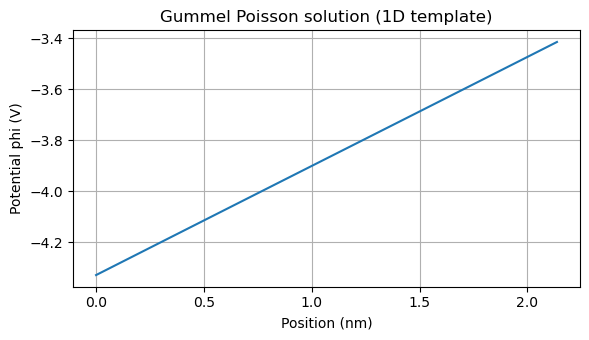

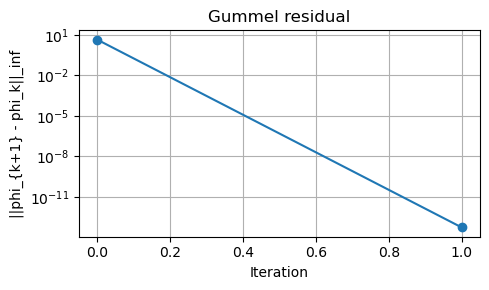

In [ ]:
from __future__ import annotations

import numpy as np
from mpi4py import MPI
from dolfinx import mesh

from poisson.solver import NonlinearPoissonSolver, DirichletBCSpec, VACUUM_PERMITTIVITY

# ------------------------------
# Simple 1D Gummel loop for Poisson–NEGF coupling (template)
# ------------------------------


def fermi_dirac_eta(eta: np.ndarray) -> np.ndarray:
    # Smooth Fermi-Dirac using log-sum-exp for stability
    eta = np.asarray(eta, dtype=float)
    return np.log1p(np.exp(-np.abs(eta))) + np.maximum(eta, 0.0)


def smear_atomic_charge(x_atoms: np.ndarray, charges: np.ndarray, x_edges: np.ndarray) -> np.ndarray:
    """Histogram atomic charges onto a 1D grid."""
    hist, _ = np.histogram(x_atoms, bins=x_edges, weights=charges)
    cell_lengths = np.diff(x_edges)
    return hist / cell_lengths


class GummelPoisson1D:
    def __init__(
        self,
        x_min: float,
        x_max: float,
        num_cells: int,
        eps_r: float,
        doping_density: np.ndarray,
        fermi_left: float,
        fermi_right: float,
        temperature_K: float,
        effective_density_nc: float,
        atom_z: np.ndarray,
        orbital_counts: np.ndarray,
        H_device: np.ndarray,
        S_device: np.ndarray,
        sigma_L: np.ndarray,
        sigma_R: np.ndarray,
        energy_grid: np.ndarray,
        phi_left_bc: float | None = None,
        phi_right_bc: float | None = None,
    ) -> None:
        self.q = 1.602176634e-19
        self.kB = 1.380649e-23
        self.kBT = self.kB * temperature_K
        self.Nc = effective_density_nc
        self.fermi_left = fermi_left
        self.fermi_right = fermi_right

        self._comm = MPI.COMM_SELF
        self.domain = mesh.create_interval(self._comm, num_cells, [x_min, x_max])
        self.dof_coords = self.domain.geometry.x
        self.x_dof = self.dof_coords[:, 0]
        self._x_min = x_min
        self._x_max = x_max

        self._left_dofs = np.array([int(np.argmin(self.x_dof))], dtype=np.int32)
        self._right_dofs = np.array([int(np.argmax(self.x_dof))], dtype=np.int32)

        self.num_cells = num_cells
        self.x_edges = np.linspace(x_min, x_max, num_cells + 1)
        self.cell_centers = np.linspace(
            x_min + (x_max - x_min) / (2 * num_cells),
            x_max - (x_max - x_min) / (2 * num_cells),
            num_cells,
        )

        if doping_density.shape[0] != num_cells:
            raise ValueError("doping_density must have length = num_cells")
        self.doping_per_dof = np.interp(self.x_dof, self.cell_centers, doping_density)

        self.atom_z = np.asarray(atom_z, dtype=float)
        self.orbital_counts = np.asarray(orbital_counts, dtype=int)
        self.H0 = np.asarray(H_device, dtype=complex)
        self.S_device = np.asarray(S_device, dtype=complex)
        self.sigma_L = np.asarray(sigma_L, dtype=complex)
        self.sigma_R = np.asarray(sigma_R, dtype=complex)
        self.energy_grid = np.asarray(energy_grid, dtype=float)

        self.phi_left = float(phi_left_bc) if phi_left_bc is not None else -fermi_left / self.q
        self.phi_right = float(phi_right_bc) if phi_right_bc is not None else -fermi_right / self.q

        self.solver = NonlinearPoissonSolver(
            domain=self.domain,
            permittivity=eps_r,
            dirichlet_bcs=[
                DirichletBCSpec(value=self.phi_left, dofs=self._left_dofs),
                DirichletBCSpec(value=self.phi_right, dofs=self._right_dofs),
            ],
            degree=1,
            eps0=VACUUM_PERMITTIVITY,
        )

    def _carrier_density(self, phi_dof: np.ndarray) -> np.ndarray:
        order = np.argsort(self.x_dof)
        x_sorted = self.x_dof[order]
        phi_sorted = phi_dof[order]
        phi_atoms = np.interp(self.atom_z, x_sorted, phi_sorted, left=phi_sorted[0], right=phi_sorted[-1])

        V_atoms = -self.q * phi_atoms
        V_orb = np.repeat(V_atoms, self.orbital_counts)
        H_shifted = self.H0 + np.diag(V_orb)

        occ_orb = charge_density_from_negf(
            energies=None,
            sigma_L=self.sigma_L,
            sigma_R=self.sigma_R,
            H_device=H_shifted,
            S_device=self.S_device,
            mu_L=self.fermi_left,
            mu_R=self.fermi_right,
            interpolate_sigmas=True,
            sigma_energy_grid=self.energy_grid,
            use_ozaki=True,
            energy_min=float(self.energy_grid.min()),
            energy_max=float(self.energy_grid.max()),
            n_uniform=241,
        )

        atom_density = orbital_density_to_atoms(occ_orb, self.orbital_counts)
        density_cells = project_atoms_to_grid(self.atom_z, atom_density, self.x_edges)
        density_dof = np.interp(self.x_dof, self.cell_centers, density_cells)
        return density_dof

    def _make_charge_callback(self, carrier_density_dof: np.ndarray):
        q = self.q
        doping = self.doping_per_dof

        def charge_callback(potential: np.ndarray, coords: np.ndarray) -> np.ndarray:
            return -q * (carrier_density_dof - doping)

        return charge_callback

    def _enforce_dirichlet(self, phi_array: np.ndarray) -> np.ndarray:
        phi_array[self._left_dofs] = self.phi_left
        phi_array[self._right_dofs] = self.phi_right
        return phi_array

    def solve_gummel(self, *, max_iters: int = 20, tol: float = 1e-5) -> tuple[np.ndarray, list[float]]:
        phi = np.zeros_like(self.x_dof)
        phi = self._enforce_dirichlet(phi)
        residuals = []
        for _ in range(max_iters):
            n_dof = self._carrier_density(phi)
            self.solver.set_charge_callback(self._make_charge_callback(n_dof))
            result = self.solver.solve(initial_guess=phi)
            phi_new = result.potential.x.array.copy()
            phi_new = self._enforce_dirichlet(phi_new)
            delta = np.linalg.norm(phi_new - phi, ord=np.inf)
            residuals.append(delta)
            phi = phi_new
            if delta < tol:
                break
        return phi, residuals


# ------------------------------
# Minimal example hookup (placeholders)
# ------------------------------

L = float((coords[:, 2].max() - coords[:, 2].min()) * 1e-10)
num_cells = 50
x_edges = np.linspace(0.0, L, num_cells + 1)

T = 300.0
fermi_L = -4.328434  # eV
fermi_R = -4.328434  # eV
eps_r_silicon = 11.7
Nc_eff = 2.8e25

kB = 1.380649e-23
q = 1.602176634e-19
ni_si = 1.5e16

atom_z = coords[mask][:, 2] * 1e-10

use_pn = True
if use_pn:
    Nd = 1e17
    Na = 5e23
    junction_x = 0.5 * L
    doping = build_pn_doping(num_cells=num_cells, Nd=Nd, Na=Na, junction_center=junction_x, x_min=0.0, x_max=L)
    V_bi = (kB * T / q) * np.log(Nd * Na / (ni_si ** 2))
    phi_left_bc = -4.328434 + 0.0
    phi_right_bc = -4.328434 + V_bi
else:
    doping = 1e17 * np.ones(num_cells)
    phi_left_bc = 0.0
    phi_right_bc = 0.0

poisson_gummel = GummelPoisson1D(
    x_min=0.0,
    x_max=L,
    num_cells=num_cells,
    eps_r=eps_r_silicon,
    doping_density=doping,
    fermi_left=fermi_L,
    fermi_right=fermi_R,
    temperature_K=T,
    effective_density_nc=Nc_eff,
    atom_z=atom_z,
    orbital_counts=counts,
    H_device=H_device,
    S_device=S_device,
    sigma_L=sigma_L_sr,
    sigma_R=sigma_R_sr,
    energy_grid=energy,
    phi_left_bc=phi_left_bc,
    phi_right_bc=phi_right_bc,
)

phi_solution, gummel_residuals = poisson_gummel.solve_gummel(max_iters=10, tol=1e-6)

order = np.argsort(poisson_gummel.x_dof)
x_plot = poisson_gummel.x_dof[order] * 1e9
phi_plot = phi_solution[order]

print(
    f"Boundary potentials (V): left={phi_solution[poisson_gummel._left_dofs][0]:.6f}, "
    f"right={phi_solution[poisson_gummel._right_dofs][0]:.6f}"
)

plt.figure(figsize=(6, 3.5))
plt.plot(x_plot, phi_plot)
plt.xlabel("Position (nm)")
plt.ylabel("Potential phi (V)")
plt.title("Gummel Poisson solution (1D template)")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 3))
plt.semilogy(gummel_residuals, marker="o")
plt.xlabel("Iteration")
plt.ylabel("||phi_{k+1} - phi_k||_inf")
plt.title("Gummel residual")
plt.grid(True, which="both")
plt.tight_layout()
plt.show()